In [1]:
import numpy as np
import matplotlib.pyplot as plt

from modules.cube import cube
from modules.hcluster import hcluster

fname = 'data/Level3_ch3-short_s3d.fits'
cb = cube(fname)




In [2]:
xfrom, xto = 4, 33
yfrom, yto = 1, 37
min_wavelength = 0
max_wavelength = np.inf

cb.set_data_limits(xfrom, xto, yfrom, yto, min_wavelength, max_wavelength)
cb.set_continuum_limits(620, 630, lambda_idx=True)

hcl = hcluster(cb)
hcl.compute(12)

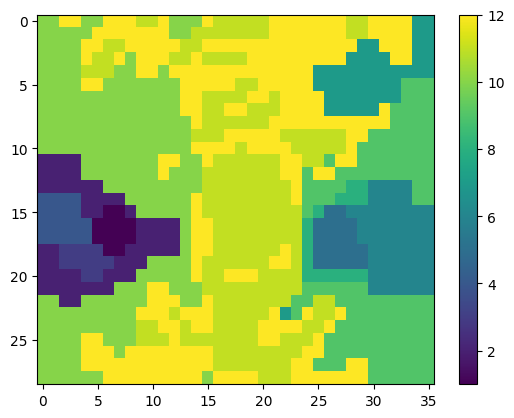

In [3]:
clusters = hcl.get_clusters(matrix=True)


plt.imshow(clusters, cmap='viridis', aspect='auto')
plt.colorbar()
plt.show()

In [4]:
# Now, use plotly
import plotly.graph_objects as go
def plot_cluster(cluster_id):
    mean_spectrum, median_spectrum, std = hcl.get_metrics_in_cluster(cluster_id)
    fig = go.Figure()
    # color: black
    # fill between, color: blue, alpha: 0.2
    fig.add_trace(go.Scatter(x=cb.lambdas, y=mean_spectrum+std, mode='lines', fill='none', name='Standard deviation', line=dict(color='orange')))
    fig.add_trace(go.Scatter(x=cb.lambdas, y=mean_spectrum-std, mode='lines', fill='tonexty', showlegend=False, line=dict(color='orange')))
    # fill between

    fig.add_trace(go.Scatter(x=cb.lambdas, y=mean_spectrum, mode='lines', name='Mean spectrum', line=dict(color='black')))
    fig.add_trace(go.Scatter(x=cb.lambdas, y=median_spectrum, mode='lines', name='Median spectrum', line=dict(color='blue')))

    # Title
    fig.update_layout(title=f'Cluster {cluster_id}', xaxis_title='Wavelength (nm)', yaxis_title='Intensity')
    fig.show()


In [5]:
for i in range(1, hcl.n+1):
    plot_cluster(i)

In [6]:
# Median of all clusters
median_spectra = [hcl.get_cluster_median(i) for i in range(1, hcl.n+1)]

fig = go.Figure()
for i, median_spectrum in enumerate(median_spectra):
    fig.add_trace(go.Scatter(x=cb.lambdas, y=median_spectrum, mode='lines', name=f'Cluster {i+1}'))

fig.update_layout(title='Median spectra of all clusters')